### [WiDS Global Datathon 2026](https://www.kaggle.com/competitions/WiDSWorldWide_GlobalDathon26/code?competitionId=125681&sortBy=scoreDescending&excludeNonAccessedDatasources=true)

Predicting Time-to-Threat for Evacuation Zones Using Survival Analysis

| | | &nbsp; | | &nbsp; | &nbsp; | &nbsp; |
|:-|:-:| :-: | :-: | :-: | :-: | :-: |
|1.|[0.97_055](https://www.kaggle.com/code/sarthakniwate13/0-97-microeda-gbsa-lgbm-rankblend-plattcalib?scriptVersionId=303994154) |&nbsp;v.2&nbsp;| [MicroEDA+GBSA+LGBM+RankBlend+PlattCalib](https://www.kaggle.com/code/sarthakniwate13/0-97-microeda-gbsa-lgbm-rankblend-plattcalib) | contributor | [Sarthak Niwate](https://www.kaggle.com/sarthakniwate13) | India |
|2.|[0.97_092](https://www.kaggle.com/code/loopassembly/0-97092-450-model-fold-fused-survival-engine?scriptVersionId=300609496) |&nbsp;v.23&nbsp;| [🏆 0.97092+ . 450-Model Fold-Fused Survival Engine](https://www.kaggle.com/code/loopassembly/0-97092-450-model-fold-fused-survival-engine/output) | contributor | [Ashutosh Anand](https://www.kaggle.com/loopassembly) | India |
|3.|[0.97_124](https://www.kaggle.com/code/dasdasdada/0-97124-gbsa-rsf-lgb-survival-engine?scriptVersionId=304973517) |&nbsp;v.10&nbsp;| [0.97124: GBSA+RSF+LGB Survival Engine](https://www.kaggle.com/code/dasdasdada/0-97124-gbsa-rsf-lgb-survival-engine) | contributor | [Utkarsh Sinha](https://www.kaggle.com/dasdasdada) | India |
|4.|[0.97_167](https://www.kaggle.com/code/furqonaryadana/0-9716-tri-survival-stack-distancestratifiedblend?scriptVersionId=302863397) |&nbsp;v.5&nbsp;| [Tri-Survival Stack . DistanceStratifiedBlend](https://www.kaggle.com/code/furqonaryadana/0-9716-tri-survival-stack-distancestratifiedblend) | expert | [Furqon Aryadana](https://www.kaggle.com/furqonaryadana) | Indonesia |
|5.|[0.97_169](https://www.kaggle.com/code/johnnyhyland/bayesian-survival-public-best?scriptVersionId=307899333) |&nbsp;v.9&nbsp;| [Bayesian Survival + public best](https://www.kaggle.com/code/johnnyhyland/bayesian-survival-public-best) | expert | [Johnny Hyland](https://www.kaggle.com/johnnyhyland) | Scotland |
|||| [ **solutions** ] . [ **their weights** ] | **type sort** | [ **correct weights** ] |
|| []() | v.1 | [ 1.,2.,3.,4.,5. ] . [ 0.08 +0.08 +0.08 +0.68 +0.08 ] | asc/desc | [ +7,+4,+2, -5,-8 ] / 100 ||
|| []() | v.2 | [ 1.,2.,3.,4.,5. ] . [ 0.08 +0.08 +0.08 +0.68 +0.08 ] | asc/desc | [ -8,-5, +2,+4,+7 ] / 100 ||

In [1]:
import numpy as np
import pandas as pd

import os,ast,shutil,copy

import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from bokeh.plotting import figure, gridplot 
from bokeh.io import output_file, show, output_notebook
output_notebook()


def bokeh_show(
        params,
        df_cross,
        show_figures1, 
        show_figures2, wps_fig2,
        color_cross):

    colors = [subm['color'] for subm in params['subm']]
    
    def dossier(js,subms,cols):
        def quant(i,js,subms,cols):
            return {"c" : i, "q" : sum([1 for subm in cols[i] if subm == subms[js]])}
        return {
            'name' : subms[js],
            'q_in' : [quant(i,js,subms,cols) for i in range(len(subms))]
        }
    alls = pd.read_csv(f'tida_desc.csv')
    matrix = [ast.literal_eval(str(row.alls)) for row in alls.itertuples()]
    subms = sorted(matrix[0])
    cols = [[data[i] for data in matrix] for i in range(len(subms))]
    df_subms = pd.DataFrame({f'col_{i}': [x[i] for x in matrix] for i in range(len(subms))})
    dossiers = [dossier(js,subms,cols) for js in range(len(subms))]
    subm_names = [one_dossier['name'] for one_dossier in dossiers]
    figures1,qss,i = [],[],0
    height = 100 if len(colors)==2\
        else 134 if len(colors)==3 else (154 if len(colors)==4 else 174)
    for one_dossier in dossiers: 
        i_col = 'alls. ' + str(one_dossier['q_in'][i]['c'])
        qs = [one['q'] for one in one_dossier['q_in']]
        x_names = [name.replace("Group","").replace("subm_","") for name in subm_names]
        width = 140
        f = figure(x_range=x_names,width=width, height=height, title=i_col)
        f.vbar(x=x_names, width=0.585, top=qs, color=colors)
        figures1.append(f)
        qss.append(qs)
        i+=1
    grid = gridplot([figures1])
    output_file('tida_alls.html')
    if show_figures1 == True: show(grid)
    sub_wts = params['subwts']
    main_wts = [subm['weight'] for subm in params['subm']]
    mms,acc_mass = [],[]
    for j in range(len(dossiers)):
        one_dossier = dossiers[j]
        qs = [one['q'] for one in one_dossier['q_in']]
        mm = [qs[h] * (main_wts[j] + sub_wts[h]) for h in range(len(sub_wts))]
        mass = sum(mm)
        mms.append(mm)
        acc_mass.append(round(mass))                        #subm_names[::-1]
    y_names = [name + " - " + str(mass) for name,mass in zip(subm_names,acc_mass)]
    f1 = figure(y_range=y_names, width=270, height=height, title='relations of general masses')
    f1.hbar(y=y_names, height=0.555, right=acc_mass, left=0, color=colors)
    output_file('tida_alls2.html')
    alls = [f'alls.{i}' for i in range(len(dossiers))]
    subm = [f'sub{i}'   for i in range(len(dossiers))] 
    mmsT  = np.asarray(mms).T
    data = {'cols' : alls}
    for i in range(len(dossiers)): data[f'sub{i}'] = mmsT[i,:]
    f2 = figure(y_range=alls, height=height, width=270, title="relations of columns masses")
    f2.hbar_stack(subm, y='cols', height=0.555, color=colors, source=data)
    qssT  = np.asarray(qss).T
    data = {'cols' : alls}
    for i in range(len(dossiers)): data[f'sub{i}'] = qssT[i,:]
    f3 = figure(y_range=alls, height=height, width=245, title="ratios in columns")
    f3.hbar_stack(subm, y='cols', height=0.555, color=colors, source=data)
    grid = gridplot([[f3,f2,f1]])
    show(grid)
    if show_figures2 == True:
        def read(params,i):
            FiN = params["path"] + params["subm"][i]["name"] + ".csv"
            target_name_back = {'target':params["target"],'pred':params["target"]}
            return pd.read_csv(FiN).rename(columns=target_name_back)
        dfs = [read(params,i) for i in range(len(params["subm"]))] + [df_cross]
        _height = 358 if len(params["subm"]) == 11 else 254
        f   = figure(width=785, height=_height)
        f.title.text = 'Click on legend entries to mute the corresponding lines'
        b,e        = 21000,21154
        line_x     = [dfs[i][b:e]['id']         for i in range(len(dfs))]
        line_y     = [dfs[i][b:e]['Exited'] for i in range(len(dfs))]
        color      = colors + [color_cross]
        alpha      = [0.8 for i in range(len(dfs)-1)] + [0.95]
        lws        = [1.0 for i in range(len(dfs)-1)] + [1.00]
        legend = subm_names + ['cross']
        for i in range(len(legend)):
            f.line(line_x[i], line_y[i], line_width=lws[i], color=color[i], alpha=alpha[i],
                   muted_color='white',legend_label=legend[i])
        f.legend.location = "top_left"
        f.legend.click_policy="mute"
        show(f)

# An example of working with Seaborn is taken from a notebook:
# https://www.kaggle.com/code/likithagedipudi/kaggle-success-factors
# Presented by an expert from Buffalo, New York, United States - Likitha Gedipudi
# https://www.kaggle.com/likithagedipudi

def seaborn_display_1(params,
                      df_cross,
                      show_figures1, show_figures2, color_cross):

    colors = [subm['color'] for subm in params['subm']]
    
    def dossier(js,subms,cols):
        def quant(i,js,subms,cols):
            return {"c" : i, "q" : sum([1 for subm in cols[i] if subm == subms[js]])}
        return {
            'name' : subms[js],
            'q_in' : [quant(i,js,subms,cols) for i in range(len(subms))]
        }
    alls = pd.read_csv(f'tida_desc.csv')
    matrix = [ast.literal_eval(str(row.alls)) for row in alls.itertuples()]
    subms = sorted(matrix[0])
    cols = [[data[i] for data in matrix] for i in range(len(subms))]
    df_subms = pd.DataFrame({f'col_{i}': [x[i] for x in matrix] for i in range(len(subms))})
    dossiers = [dossier(js,subms,cols) for js in range(len(subms))]
    subm_names = [one_dossier['name'] for one_dossier in dossiers]
    
    nqs,qss,i = [],[],0
    
    for one_dossier in dossiers: 
        qs = [one['q'] for one in one_dossier['q_in']]
        x_names = [name.replace("Group","").replace("subm_","") for name in subm_names]
        qss.append(qs)
        nqs.append({'n':x_names, 'q':qs})
        i+=1
    
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.size']      = 7
    plt.rcParams['axes.titlesize'] = 9
    plt.rcParams['axes.labelsize'] = 8

    len_nqs = len(nqs) if len(nqs) > 3 else 4

    fig, axes = plt.subplots(2, len_nqs, figsize=(2.1*len_nqs, 4))
    
    def ric(j, i, n, q, colors):
        ax1 = axes[j, i]
        bars1 = ax1.bar(n, q, color=colors)
        ax1.set_title(f'ratios in alls.col {i}', fontweight='bold')
        ax1.set_xticklabels(n, rotation=45, ha='right')
        i = 0
        for bar, val in zip(bars1, q):
            if i != 0:
                ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                         f'{val:,.0f}', ha='center', va='bottom', fontsize=8)
            i += 1

    lm_max = 0
    for i in range(len(nqs)):
        for q in nqs[i]['q']:
            if q > lm_max: lm_max = q  
    lm_colors = ['whitesmoke'] + colors
    for nq in nqs:
        nq['n'].insert(0,'')
        nq['q'].insert(0, lm_max*1.13)

    for i in range(len(nqs)): ric(0, i, nqs[i]['n'], nqs[i]['q'], lm_colors)

    ax10 = axes[1, 0]
    #--------------------------------------------------------------------------------
    sub_wts = params['subwts']
    main_wts = [subm['weight'] for subm in params['subm']]
    mms,acc_mass = [],[]
    for j in range(len(dossiers)):
        one_dossier = dossiers[j]
        qs = [one['q'] for one in one_dossier['q_in']]
        mm = [qs[h] * (main_wts[j] + sub_wts[h]) for h in range(len(sub_wts))]
        mass = sum(mm)
        mms.append(mm)
        acc_mass.append(round(mass))
    acc_mass = acc_mass
    y_names = [str(mass) + " - " + name for name,mass in zip(subm_names,acc_mass)]
    colors  .insert(0,'whitesmoke')
    y_names .insert(0,'')
    acc_mass.insert(0, max(acc_mass) * 1.13)
    irbis = ax10.barh(y_names[::-1], acc_mass[::-1], color=colors[::-1])
    ax10.set_title('relations of g.masses', fontweight='bold')
    ax10.set_xlabel('weights')


    ax11 = axes[1, 1]
    #--------------------------------------------------------------------------------
    corr_matrix = alls[subm_names].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    mask = 0.5*mask
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', 
                center=0,fmt='.3f', square=True, linewidths=0.5, ax=ax11,
                cbar_kws={'shrink': 0.8})
    ax11.set_title('Correlation Matrix', fontweight='bold', fontsize=9)
    ax11.set_xticklabels(subm_names, rotation=45, ha='right')

    ax13 = axes[1,3]
    #--------------------------------------------------------------------------------
    ip1 = len(nqs)-1
    ip2 = len(nqs)-3
    sample  = alls.sample(min(100_000, len(alls)), random_state=42)
    scatter = ax13.scatter(np.log10(sample[subm_names[ip2]] + 1), 
                           np.log10(sample[subm_names[ip1]] + 1), 
                           c=sample[params['id_target'][1]], cmap='viridis', alpha=0.5, s=10)
    ax13.set_title(f'{subm_names[ip2]} vs {subm_names[ip1]}', fontweight='bold', fontsize=8)
    plt.colorbar(scatter, ax=ax13, label='Score')
    if len(nqs) >= 5:
        ax14 = axes[1,4]
        #--------------------------------------------------------------------------------
        ip1 = len(nqs)-1
        ip2 = len(nqs)-4
        sample  = alls.sample(min(100_000, len(alls)), random_state=42)
        scatter = ax14.scatter(np.log10(sample[subm_names[ip2]] + 1), 
                               np.log10(sample[subm_names[ip1]] + 1), 
                               c=sample[params['id_target'][1]], cmap='viridis', alpha=0.5, s=10)
        ax14.set_title(f'{subm_names[ip2]} vs {subm_names[ip1]}', fontweight='bold', fontsize=8)
        plt.colorbar(scatter, ax=ax14, label='Score')

    
    ax12 = axes[1, 2]
    #--------------------------------------------------------------------------------
    colors = [subm['color'] for subm in params['subm']]
    
    for subm,color in zip(subm_names,colors):
        subm_data = alls[subm]
        ax12.hist(np.log10(subm_data + 1), bins=30, alpha=0.5, label=subm, color=color)
    ax12.set_title('(Log Scale)', fontweight='bold')
    ax12.set_xlabel('log10')
    ax12.set_ylabel('Frequency')
    ax12.legend()
 
    plt.tight_layout()
    plt.show()


def seaborn_display_2(params, file_name_cross=""):
    plt.figure(figsize=(9, 2.5))
    for subm in params['subm']:
        pred = pd.read_csv(params['path']+subm['name']+'.csv')[params['id_target'][1]]
        sns.kdeplot(pred, label = subm['name'], linewidth = 0.5)
    if file_name_cross != '':
        pred = pd.read_csv(file_name_cross)[params['id_target'][1]]
        sns.kdeplot(pred, label = 'blend', linewidth = 1, linestyle = 'dashed')
    plt.title("KDE")
    plt.xlabel("target")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def matrix_vs(path,fs_names):
    def load(path,fs_names):
        dfs = [pd.read_csv(path + name_subm +'.csv') for name_subm in fs_names]
        for i in range(len(dfs)):
            dfs[i] = dfs[i].rename(columns={"Exited": f'{fs_names[i]}'})
        dfsm = pd.merge(dfs[0], dfs[1], on="id")
        for i in range(2,len(dfs)):
            dfsm = pd.merge(dfsm,dfs[i],on='id')
        return dfsm   
    def make_list_vs(fs_names):
        list = []
        for i in range(0,len(fs_names)-1):
            for j in range(i+1,len(fs_names)):
                list.append(fs_names[i] + "_vs_" + fs_names[j])
        return list
    def get_mvs(dfs, list_vs):
        def get_abs_distance(x,t1,t2):
            return abs(x[t1]-x[t2])
        for vs in list_vs:
            t = vs.split('_vs_')
            dfs[vs] = dfs.apply(lambda x: get_abs_distance(x,t[0],t[1]), axis=1)
        return dfs   
    def distance_vs(name, st_names, list_vs, dfs):
        distances = []
        for st in st_names:
            vs_between = name + "_vs_" + st
            if vs_between not in list_vs:
                distances.append(0)
            else: distances.append(round(dfs[vs_between].sum()))
        return distances
    dfs = load(path,fs_names)
    list_vs = make_list_vs(fs_names)
    mvs = get_mvs(dfs, list_vs)
    m1 = pd.DataFrame({'subm':fs_names})
    m2 = pd.DataFrame({ name :distance_vs(name, fs_names, list_vs, mvs) for name in fs_names})
    matrix = pd.concat([m1,m2],axis=1)
    return matrix


def display_distances(params):
    files = [subm['name'] for subm in params['subm']]
    distances = matrix_vs ( params['path'], files )            
    display(distances)


def arr_colors(color):
    dskb,mvr = 'deepskyblue','mediumvioletred'
    sg = ['darkgray','silver','gainsboro']
    if color=='red'   or color=='R': return ['firebrick','red','crimson','tomato']     + sg
    if color=='Red'   or color=='r': return ['red','tomato','crimson']                 + sg
    if color=='Green' or color=='G': return ['darkgreen','limegreen','green','lime']   + sg
    if color=='Blue'  or color=='B': return ['midnightblue','blue','mediumblue',dskb]  + sg
    if color=='RGB'   or color=='S': return ['mediumblue','darkgreen','crimson']       + sg
    if color=='RGBM'  or color=='M': return [mvr,'darkorchid','darkmagenta','magenta'] + sg
    return ['black','dimgray','gray'] + sg


def convert(schema):
    colors = arr_colors(schema[2])
    dicts  = [
        {'name': schema[0][i],'weight':schema[1][i],'color':colors[i]} 
        for i in range(len(schema[0]))
    ]
    return {'subm':dicts}


def h_blend(
        params, _update={},
        cross='silver',
        details=False,
        fig1=False, fig2=False, wf2=555, 
        dtls=False, dist=False, subm=''):

    if isinstance(params, list): params = convert(params)

    if 'path' in _update: params.update(_update)
    
    color_cross, dk  = cross, copy.deepcopy(params)

    if details == True:
        dist = True
        show_details,show_figures1,show_figures2 = True,True,True
    else:
        show_details,show_figures1,show_figures2 = dtls,fig1,fig2
        
    file_short_names = [subm['name'] for subm in params['subm']]
    type_sort    = params['type_sort'][0]
    dk['asc']    = params['type_sort'][1]
    dk['desc']   = params['type_sort'][2]
    dk['id']     = params['id_target'][0]
    dk['target'] = params['id_target'][1]

    if 'task' in params: dk['task'] = params['task']
    
    def read(dk,i):
        tnm = dk["subm"][i]["name"]
        FiN = dk["path"] + tnm + ".csv"
        df = pd.read_csv(FiN).rename(columns={'target':tnm, 'pred':tnm, dk["target"]:tnm})
        if 'task' in dk and dk['task'][0]=='round':
            df[tnm] = df[tnm].round(dk['task'][1])
        return df 
        
    def merge(dfs_subm):
        df_subms = pd.merge(dfs_subm[0],  dfs_subm[1], on=[dk['id']])
        for i in range(2, len(dk["subm"])): 
            df_subms = pd.merge(df_subms, dfs_subm[i], on=[dk['id']])
        return df_subms
        
    def da(dk,sorting_direction,show_details):
        
        df_subms = merge([read(dk,i) for i in range(len(dk["subm"]))])
        cols = [col for col in df_subms.columns if col != dk['id']]
        short_name_cols = [c for c in cols]
        
        def alls1(x, sd=sorting_direction,cs=cols):
            reverse = True if sd=='desc' else False
            tes = {c: x[c] for c in cs}.items()
            subms_sorted = [t[0] for t in sorted(tes,key=lambda k:k[1],reverse=reverse)]
            return subms_sorted

        import random

        def alls2(x, sd=sorting_direction,cs=cols):
            reverse = True if sd=='desc' else False
            tes = {c: x[c] for c in cs}.items()
            subms_random = [t[0] for t in tes]
            random.shuffle(subms_random)
            return subms_random

        alls = alls1 if type_sort == 'asc/desc' else alls2
            
        def summa(x,cs,wts,ic_alls): 
            return sum([x[cs[j]] * (wts[0][j] + wts[1][ic_alls[j]]) for j in range(len(cs))])
            
        wts = [[[e['weight'] for e in dk["subm"]], [w for w in dk["subwts"]]]]
          
        def correct(x, cs=cols, wts=wts):
            i = [x['alls'].index(c) for c in short_name_cols]
            return summa(x,cs,wts[0],i)

        if len(wts) == 1:
            correct_sub_weights = [wt for wt in dk["subwts"]]
            weights = [subm['weight'] for subm in dk["subm"]]
            def correct(x, cs=cols, w=weights, cw=correct_sub_weights):
                ic = [x['alls'].index(c) for c in short_name_cols]
                cS = [x[cols[j]] * (w[j] + cw[ic[j]]) for j in range(len(cols))]
                return sum(cS)
                
        if len(wts) > 1 or "subwts2" in dk:

            wts = [
                [[e['weight'] for e in dk["subm"]], [w for w in dk["subwts" ]]],
                [[e['weight'] for e in dk["subm2"]],[w for w in dk["subwts2"]]],
                [[e['weight'] for e in dk["subm3"]],[w for w in dk["subwts3"]]],
            ]

            def correct(x, cs=cols, wts=wts):
                i = [x['alls'].index(c) for c in short_name_cols]
                if   0.0540 < x['mx-m'] <= 0.0740: return summa(x,cs,wts[2],i)
                if   0.0000 < x['mx-m'] <= 0.0050: return summa(x,cs,wts[1],i)
                else:                              return summa(x,cs,wts[0],i)
                   
        def amxm(x, cs=cols):
            list_values = x[cs].to_list()
            mxm = abs(max(list_values)-min(list_values))
            return mxm

        if len(wts) > 1 or "subwts2" in dk:
            df_subms['mx-m']   = df_subms.apply(lambda x: amxm   (x), axis=1)
        df_subms['alls']       = df_subms.apply(lambda x: alls   (x), axis=1)
        df_subms[dk["target"]] = df_subms.apply(lambda x: correct(x), axis=1)
        schema_rename = { old_nc:new_shnc for old_nc, new_shnc in zip(cols, short_name_cols) }
        df_subms = df_subms.rename(columns=schema_rename)
        df_subms = df_subms.rename(columns={dk["target"]:"ensemble"})
        df_subms.insert(loc=1, column=' _ ', value=['   '] * len(df_subms))
        df_subms[' _ '] = df_subms[' _ '].astype(str)
        pd.set_option('display.max_rows',100)
        pd.set_option('display.float_format', '{:.5f}'.format)
        if len(wts) > 1: 
            vcols = [dk['id']] + [' _ '] + short_name_cols + [' _ '] + ['mx-m'] + [' _ '] +\
                      ['alls'] + [' _ '] + ['ensemble']
        else:
            vcols = [dk['id']] + [' _ '] + short_name_cols + [' _ '] +\
                      ['alls'] + [' _ '] + ['ensemble']
        df_subms = df_subms[vcols]
        if show_details and sorting_direction=='desc': display(df_subms.head(5))
        pd.set_option('display.float_format', '{:.5f}'.format)
        df_subms = df_subms.rename(columns={"ensemble":dk["target"]})
        if sorting_direction=='desc': 
            df_subms.to_csv(f'tida_{sorting_direction}.csv', index=False)
        return df_subms[[dk['id'],dk['target']]]
   
    def ensemble_da(dk,        show_details): 
        dfD    = da(dk,'desc', show_details)
        dfA    = da(dk,'asc',  show_details)
        dfA[dk['target']] = dk['desc']*dfD[dk['target']] + dfA[dk['target']]*dk['asc']
        return dfA

    da = ensemble_da(dk,show_details)

    # bokeh_show(dk, da, show_figures1, False, wf2, color_cross)

    if subm != '': da.to_csv(subm, index=False)

    seaborn_display_1(dk, da, show_figures1, False, color_cross)

    #display_distances(params)

    seaborn_display_2(params, file_name_cross=subm)
    
    return  da

Loading BokehJS ...

In [2]:
Ensemble_of_solutions = ['0.97055','0.97092','0.97124','0.97167','0.97169']
weights               = [ 0.08,     0.08,     0.08,     0.68,     0.08    ]

correct = [w/100 for w in[ -8,-5, +2,+4,+7 ]]

In [3]:
path_work = '/kaggle/working/wpage/'
path_data = '/kaggle/input/datasets/nina2025/wids-global-datathon-2026-01-28/'

if os.path.isdir(path_work): shutil.rmtree(path_work)           
    
os.mkdir(path_work)

In [4]:
def read_subm(path, name): 
    return pd.read_csv(f'{path}{name}.csv')

def split_df(df):
    df12h = df.copy().drop(columns=[           'prob_24h','prob_48h','prob_72h'])
    df24h = df.copy().drop(columns=['prob_12h',           'prob_48h','prob_72h'])
    df48h = df.copy().drop(columns=['prob_12h','prob_24h',           'prob_72h'])
    df72h = df.copy().drop(columns=['prob_12h','prob_24h','prob_48h'           ])
    return [df12h,df24h,df48h,df72h]

def save_dfs(dfs, path, prefix_name):
    dfs[0].to_csv(f'{path}{prefix_name}_12h.csv',index=False)
    dfs[1].to_csv(f'{path}{prefix_name}_24h.csv',index=False)
    dfs[2].to_csv(f'{path}{prefix_name}_48h.csv',index=False)
    dfs[3].to_csv(f'{path}{prefix_name}_72h.csv',index=False)
    return [f'{prefix_name}_{hours}' for hours in '12h,24h,48h,72h'.split(',')]

def split_and_save(df, path, prefix_name):
    dfs = split_df(df)
    short_file_names = save_dfs(dfs, path, prefix_name)
    return short_file_names

def reGroup(i,Ms):
    group_i_col = [M[i] for M in Ms]
    return group_i_col

In [5]:
df1 = read_subm(path_data, Ensemble_of_solutions[0])
df2 = read_subm(path_data, Ensemble_of_solutions[1])
df3 = read_subm(path_data, Ensemble_of_solutions[2])
df4 = read_subm(path_data, Ensemble_of_solutions[3])
df5 = read_subm(path_data, Ensemble_of_solutions[4])

df1.head(4)                                                           # for example

dfs1 = split_and_save(df1, path_work,'m1')
dfs2 = split_and_save(df2, path_work,'m2')
dfs3 = split_and_save(df3, path_work,'m3')
dfs4 = split_and_save(df4, path_work,'m4')
dfs5 = split_and_save(df5, path_work,'m5')

dfs = [dfs1,dfs2,dfs3,dfs4,dfs5]

names12h = reGroup (0, dfs)
names24h = reGroup (1, dfs)
names48h = reGroup (2, dfs)
names72h = reGroup (3, dfs)

for names in [names12h,names24h,names48h,names72h]: 
    print('>',names)

pd.read_csv(f'{path_work}{names12h[0]}.csv').head(4)                  # for example

> ['m1_12h', 'm2_12h', 'm3_12h', 'm4_12h', 'm5_12h']
> ['m1_24h', 'm2_24h', 'm3_24h', 'm4_24h', 'm5_24h']
> ['m1_48h', 'm2_48h', 'm3_48h', 'm4_48h', 'm5_48h']
> ['m1_72h', 'm2_72h', 'm3_72h', 'm4_72h', 'm5_72h']


,event_id,prob_12h
0,10662602,0.014768
1,13353600,0.710951
2,13942327,0.014639
3,16112781,0.668664


## **12** h

,event_id,_,m1_12h,m2_12h,m3_12h,m4_12h,m5_12h,_,alls,_,ensemble
0,10662602,,0.01477,0.00000,0.01484,0.01485,0.01475,,"[m4_12h, m3_12h, m1_12h, m5_12h, m2_12h]",,0.01260
1,13353600,,0.71095,0.70836,0.71953,0.71816,0.71651,,"[m3_12h, m4_12h, m5_12h, m1_12h, m2_12h]",,0.71566
2,13942327,,0.01464,0.00000,0.01470,0.01472,0.01462,,"[m4_12h, m3_12h, m1_12h, m5_12h, m2_12h]",,0.01249
3,16112781,,0.66866,0.66973,0.69635,0.69430,0.69349,,"[m3_12h, m4_12h, m5_12h, m2_12h, m1_12h]",,0.68742
4,17132808,,0.01905,0.00000,0.01898,0.01896,0.01886,,"[m1_12h, m3_12h, m4_12h, m5_12h, m2_12h]",,0.01611


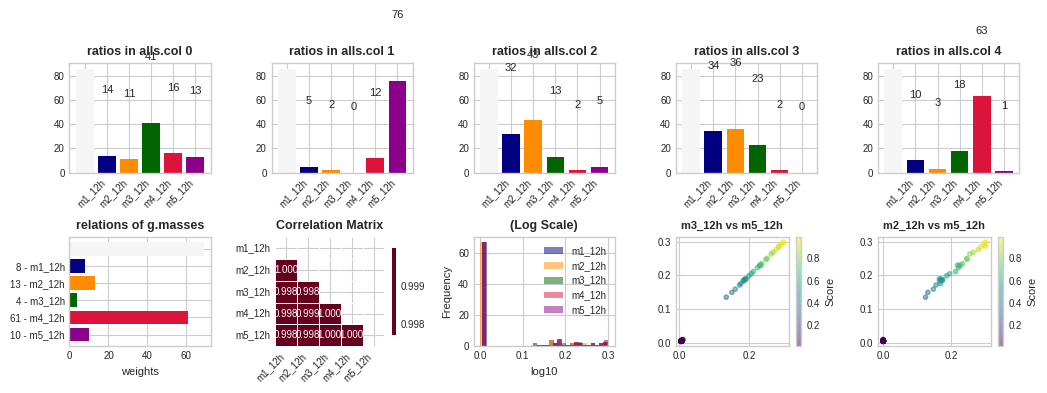

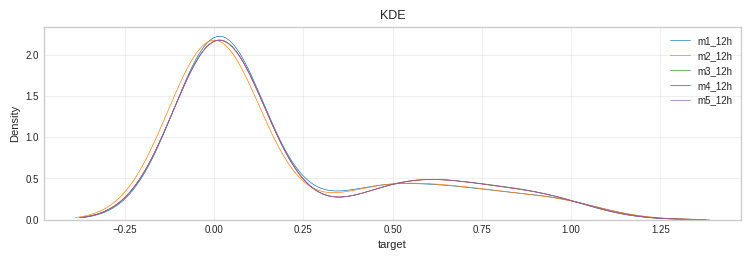

In [6]:
params = {
  'path'     : path_work,
  'id_target': ['event_id',"prob_12h"],          
  'type_sort': ['asc/desc',0.30,0.70],
  'subwts'   : correct,
  'subm'     : [
      {'name': names12h[0], 'weight':weights[0], 'color':'navy'},
      {'name': names12h[1], 'weight':weights[1], 'color':'darkorange'},
      {'name': names12h[2], 'weight':weights[2], 'color':'darkgreen'},
      {'name': names12h[3], 'weight':weights[3], 'color':'crimson'},
      {'name': names12h[4], 'weight':weights[4], 'color':'darkmagenta'},
  ]}
df_12h = h_blend(params, details=True)

## **24** h

,event_id,_,m1_24h,m2_24h,m3_24h,m4_24h,m5_24h,_,alls,_,ensemble
0,10662602,,0.02576,0.00000,0.04766,0.02459,0.02439,,"[m3_24h, m1_24h, m4_24h, m5_24h, m2_24h]",,0.02091
1,13353600,,0.94703,0.94144,0.92832,0.93133,0.92950,,"[m1_24h, m2_24h, m4_24h, m5_24h, m3_24h]",,0.93096
2,13942327,,0.02547,0.00000,0.04753,0.02429,0.02410,,"[m3_24h, m1_24h, m4_24h, m5_24h, m2_24h]",,0.02066
3,16112781,,0.93079,0.92436,0.92059,0.92252,0.92134,,"[m1_24h, m2_24h, m4_24h, m5_24h, m3_24h]",,0.92214
4,17132808,,0.03358,0.00000,0.05326,0.04784,0.04751,,"[m3_24h, m4_24h, m5_24h, m1_24h, m2_24h]",,0.03892


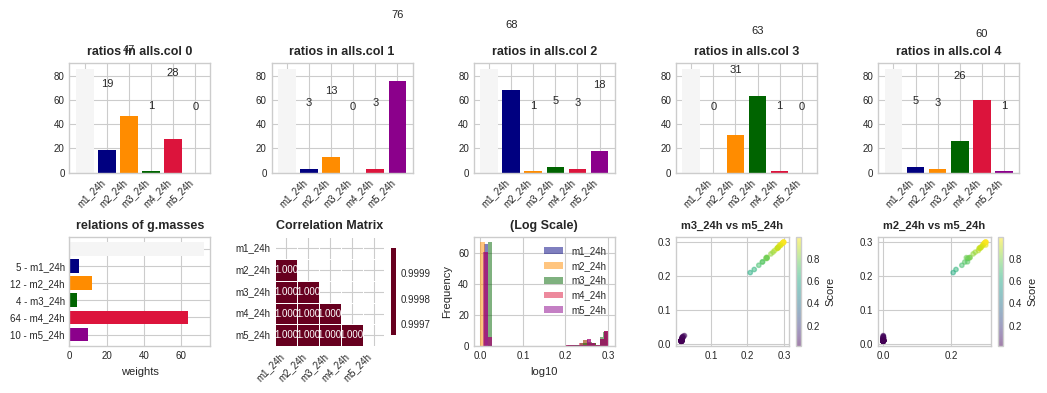

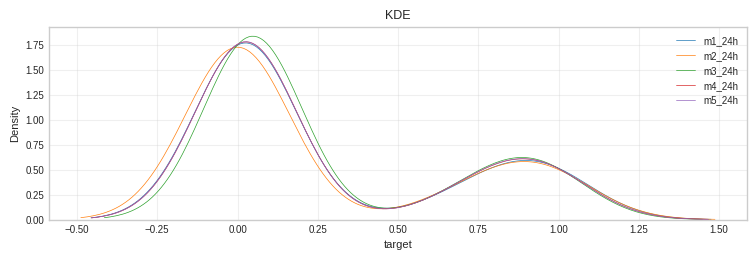

In [7]:
params = {
  'path'     : path_work,
  'id_target': ['event_id',"prob_24h"],          
  'type_sort': ['asc/desc',0.30,0.70],
  'subwts'   : correct,
  'subm'     : [
      {'name': names24h[0], 'weight':weights[0], 'color':'navy'},
      {'name': names24h[1], 'weight':weights[1], 'color':'darkorange'},
      {'name': names24h[2], 'weight':weights[2], 'color':'darkgreen'},
      {'name': names24h[3], 'weight':weights[3], 'color':'crimson'},
      {'name': names24h[4], 'weight':weights[4], 'color':'darkmagenta'},
  ]}
df_24h = h_blend(params, details=True)

## **48** h

,event_id,_,m1_48h,m2_48h,m3_48h,m4_48h,m5_48h,_,alls,_,ensemble
0,10662602,,0.02576,0.00000,0.04973,0.02731,0.02708,,"[m3_48h, m4_48h, m5_48h, m1_48h, m2_48h]",,0.02300
1,13353600,,0.98838,0.98589,0.95921,0.96323,0.96264,,"[m1_48h, m2_48h, m4_48h, m5_48h, m3_48h]",,0.96324
2,13942327,,0.02547,0.00000,0.04963,0.02724,0.02703,,"[m3_48h, m4_48h, m5_48h, m1_48h, m2_48h]",,0.02292
3,16112781,,0.98381,0.98039,0.95655,0.96019,0.95995,,"[m1_48h, m2_48h, m4_48h, m5_48h, m3_48h]",,0.96022
4,17132808,,0.03358,0.00000,0.05710,0.05213,0.05186,,"[m3_48h, m4_48h, m5_48h, m1_48h, m2_48h]",,0.04206


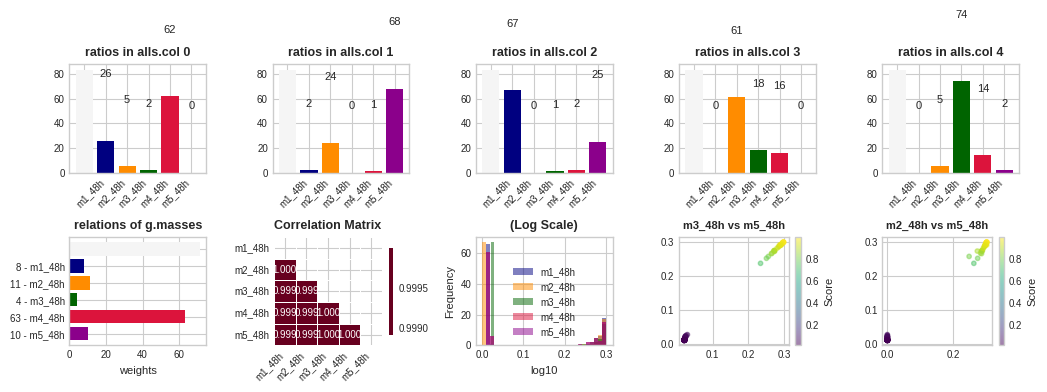

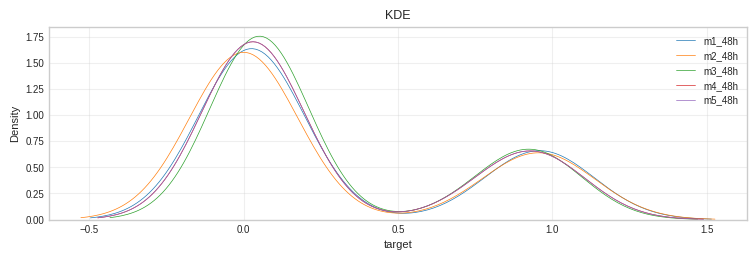

In [8]:
params = {
  'path'     : path_work,
  'id_target': ['event_id',"prob_48h"],          
  'type_sort': ['asc/desc',0.30,0.70],
  'subwts'   : correct,
  'subm'     : [
      {'name': names48h[0], 'weight':weights[0], 'color':'navy'},
      {'name': names48h[1], 'weight':weights[1], 'color':'darkorange'},
      {'name': names48h[2], 'weight':weights[2], 'color':'darkgreen'},
      {'name': names48h[3], 'weight':weights[3], 'color':'crimson'},
      {'name': names48h[4], 'weight':weights[4], 'color':'darkmagenta'},
  ]}
df_48h = h_blend(params, details=True)

## **72** h

,event_id,_,m1_72h,m2_72h,m3_72h,m4_72h,m5_72h,_,alls,_,ensemble
0,10662602,,1.00000,0.00000,1.00000,1.00000,1,,"[m1_72h, m3_72h, m4_72h, m5_72h, m2_72h]",,0.85000
1,13353600,,1.00000,1.00000,1.00000,1.00000,1,,"[m1_72h, m2_72h, m3_72h, m4_72h, m5_72h]",,1.00000
2,13942327,,1.00000,0.00000,1.00000,1.00000,1,,"[m1_72h, m3_72h, m4_72h, m5_72h, m2_72h]",,0.85000
3,16112781,,1.00000,1.00000,1.00000,1.00000,1,,"[m1_72h, m2_72h, m3_72h, m4_72h, m5_72h]",,1.00000
4,17132808,,1.00000,0.00000,1.00000,1.00000,1,,"[m1_72h, m3_72h, m4_72h, m5_72h, m2_72h]",,0.85000


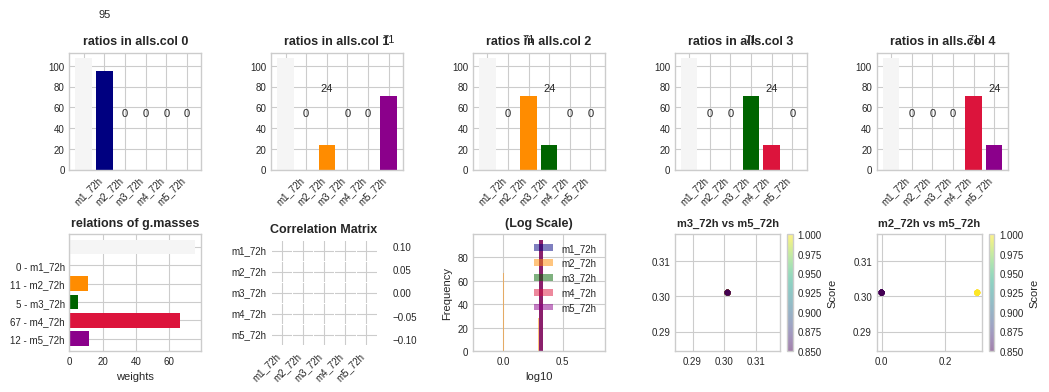

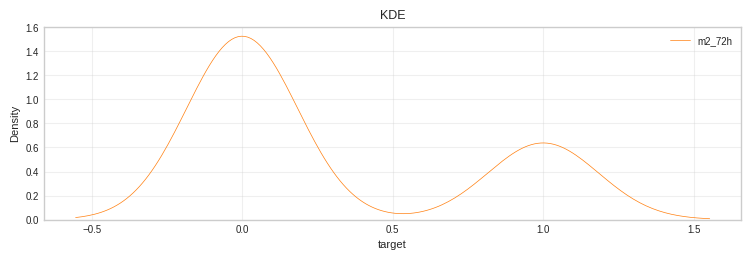

In [9]:
params = {
  'path'     : path_work,
  'id_target': ['event_id',"prob_72h"],          
  'type_sort': ['asc/desc',0.30,0.70],
  'subwts'   : correct,
  'subm'     : [
      {'name': names72h[0], 'weight':weights[0], 'color':'navy'},
      {'name': names72h[1], 'weight':weights[1], 'color':'darkorange'},
      {'name': names72h[2], 'weight':weights[2], 'color':'darkgreen'},
      {'name': names72h[3], 'weight':weights[3], 'color':'crimson'},
      {'name': names72h[4], 'weight':weights[4], 'color':'darkmagenta'},
  ]}
df_72h = h_blend(params, details=True)

In [10]:
if os.path.isdir(path_work): shutil.rmtree(path_work)

In [11]:
df = pd.merge(df_12h, df_24h, on='event_id')
df = pd.merge(df,     df_48h, on='event_id')
df = pd.merge(df,     df_72h, on='event_id')

## Submit

In [12]:
df.to_csv('submission.csv',index=False)

df.head(11)

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.01327,0.02309,0.02528,0.89500
1,13353600,0.71636,0.93213,0.96518,1.00000
2,13942327,0.01316,0.02284,0.02520,0.89500
3,16112781,0.68933,0.92268,0.96200,1.00000
4,17132808,0.01697,0.04170,0.04513,0.89500
5,17445696,0.01188,0.01982,0.02188,0.89500
6,17599982,0.01279,0.02244,0.02470,0.89500
7,18750374,0.49103,0.74480,0.85043,1.00000
8,21365245,0.01211,0.01965,0.02363,0.89500
9,23634840,0.51406,0.78215,0.88251,1.00000
